In [88]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pl
import warnings
warnings.filterwarnings("ignore")

In [89]:
data = pd.read_csv('stud.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [90]:
data['gender']= data['gender'].map({'male':0, 'female':1})

In [91]:
data['parental_level_of_education'] = data['parental_level_of_education'].replace(
    'some high school',
    'high school'
)

In [92]:
mapping = {
    'high school': 0,
    'some college': 1,
    "associate's degree": 2,
    "bachelor's degree": 3,
    "master's degree": 4
}

data['parental_level_of_education'] = data['parental_level_of_education'].map(mapping)

In [93]:
data['test_preparation_course']=data['test_preparation_course'].map({'none':0,'completed':1})

In [94]:
data.duplicated().sum()

np.int64(0)

In [95]:
data[data.duplicated()]

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score


In [96]:
print(f"Unique values : \n{data.nunique()}")
print(f"Unique values sum : \n{data.nunique().sum()}")

Unique values : 
gender                          2
race_ethnicity                  5
parental_level_of_education     5
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64
Unique values sum : 
246


In [97]:
data.describe()

,gender,parental_level_of_education,test_preparation_course,math_score,reading_score,writing_score
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,0.518000,1.260000,0.358000,66.08900,69.169000,68.054000
std,0.499926,1.238521,0.479652,15.16308,14.600192,15.195657
min,0.000000,0.000000,0.000000,0.00000,17.000000,10.000000
25%,0.000000,0.000000,0.000000,57.00000,59.000000,57.750000
50%,1.000000,1.000000,0.000000,66.00000,70.000000,69.000000
75%,1.000000,2.000000,1.000000,77.00000,79.000000,79.000000
max,1.000000,4.000000,1.000000,100.00000,100.000000,100.000000


In [98]:
data = data.drop(columns=['race_ethnicity','lunch'])

<Figure size 640x480 with 0 Axes>

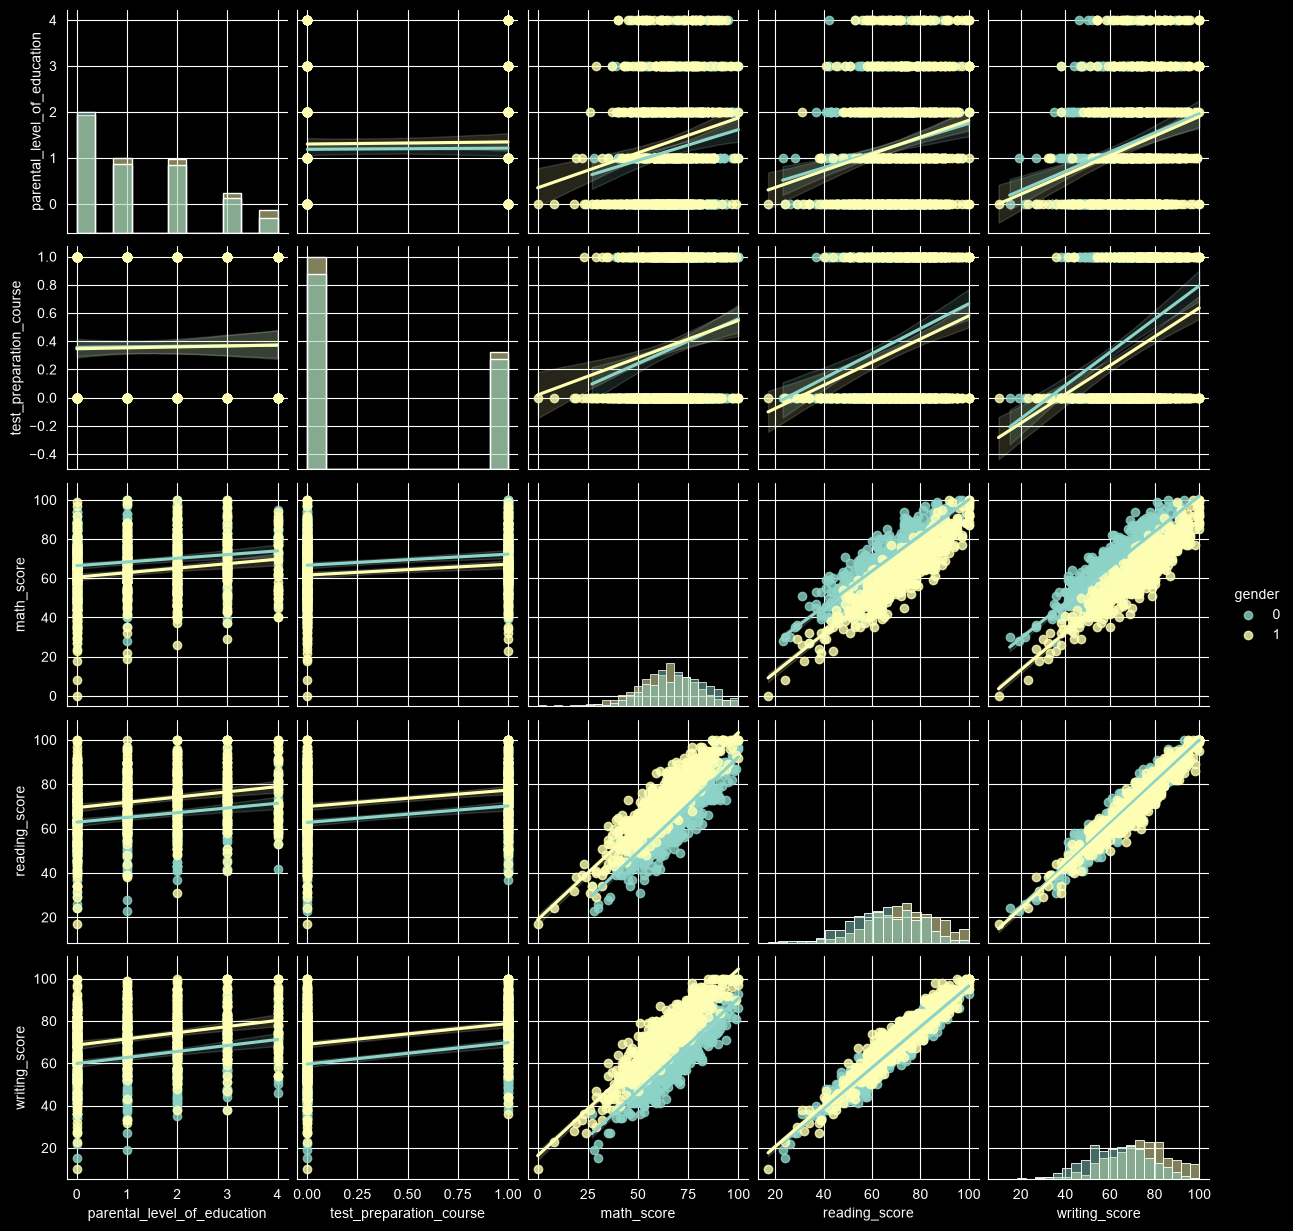

In [99]:
pl.figure()
sns.pairplot(data, hue='gender' ,kind='reg',diag_kind='hist')

In [106]:
Q1 = data.quantile(.25)
Q3 = data.quantile(.75)
IQR = Q3 - Q1
Upper = Q3+1.5*IQR
Low = Q1-1.5*IQR
is_outlier = (data < Low) | (data > Upper)
clean_data = data[~is_outlier.any(axis=1)]

<Figure size 640x480 with 0 Axes>

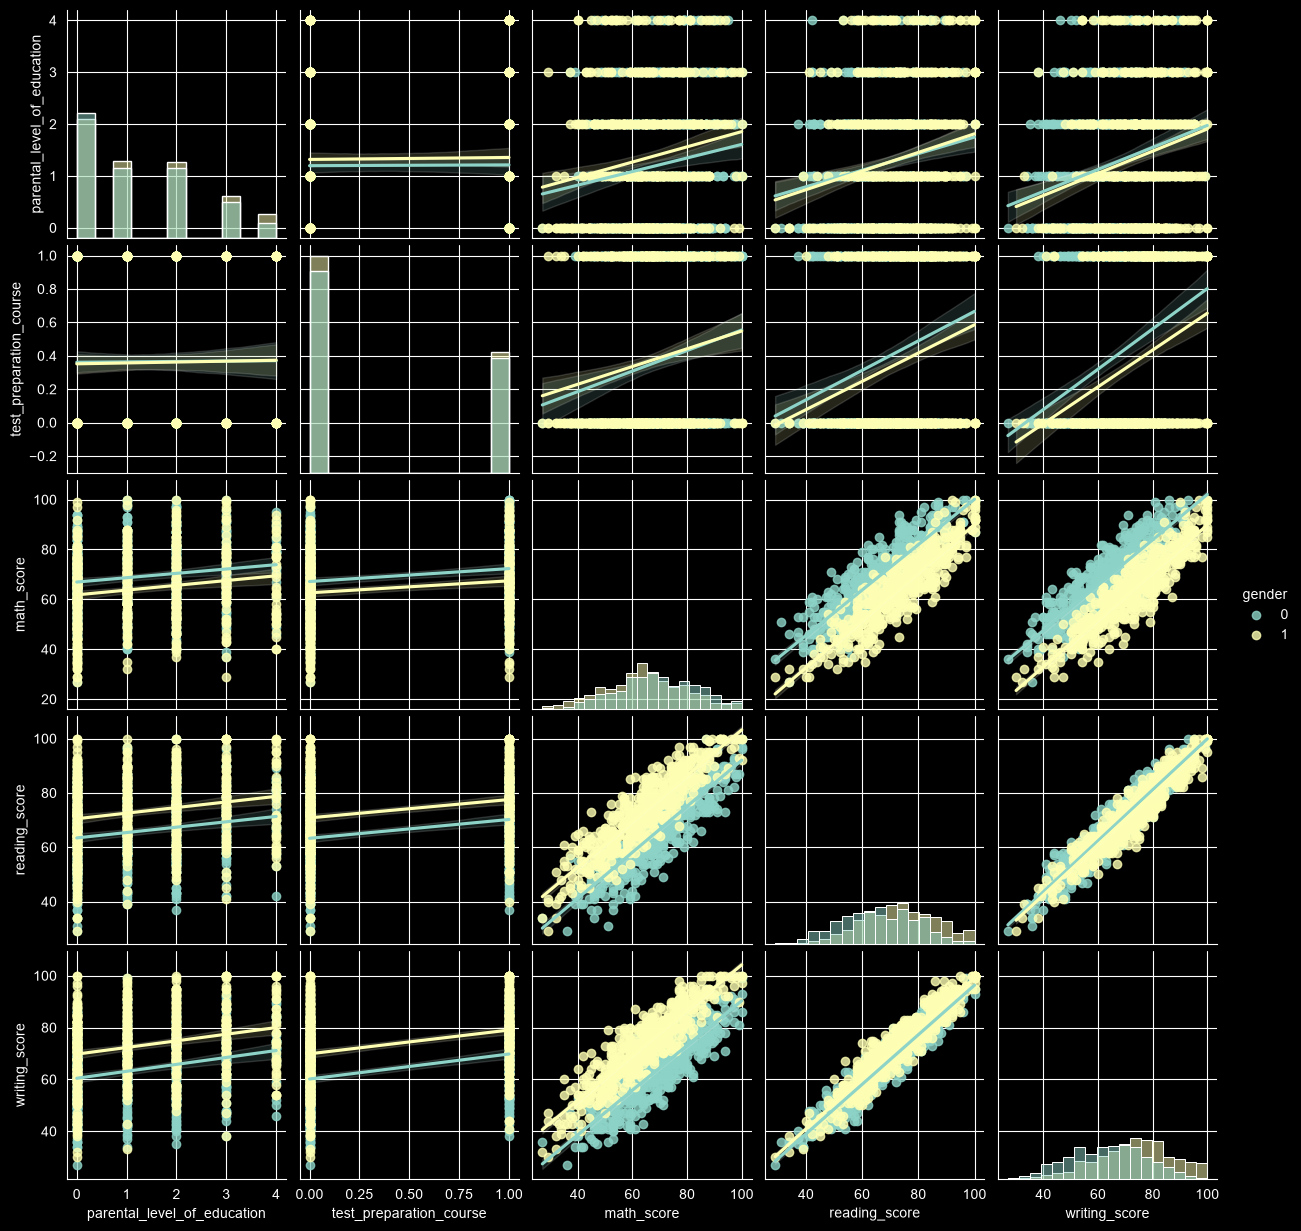

In [107]:
pl.figure()
sns.pairplot(clean_data, hue='gender' ,kind='reg',diag_kind='hist')